SetUp

In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.9 MB/s eta 0:00:00


In [4]:
!wget "https://raw.githubusercontent.com/MHM-Rajpoot/Deep-Learning/refs/heads/main/Tutorial/Week%2009/Data/image.jpg"
!wget "https://github.com/MHM-Rajpoot/Deep-Learning/raw/refs/heads/main/Tutorial/Week%2009/Data/video.mp4"

--2025-11-10 16:25:35--  https://raw.githubusercontent.com/MHM-Rajpoot/Deep-Learning/refs/heads/main/Tutorial/Week%2009/Data/image.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 356852 (348K) [image/jpeg]
Saving to: ‘image.jpg.2’

image.jpg.2         100%[===================>] 348.49K  --.-KB/s    in 0.02s   

2025-11-10 16:25:35 (16.9 MB/s) - ‘image.jpg.2’ saved [356852/356852]

--2025-11-10 16:25:35--  https://github.com/MHM-Rajpoot/Deep-Learning/raw/refs/heads/main/Tutorial/Week%2009/Data/video.mp4
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/MHM-Rajpoot/Deep-Learning/refs/heads/main/

In [5]:
!ls -alh

total 8.0M
drwxr-xr-x 1 root root 4.0K Nov 10 16:25 .
drwxr-xr-x 1 root root 4.0K Nov 10 16:22 ..
drwxr-xr-x 4 root root 4.0K Nov  5 14:33 .config
-rw-r--r-- 1 root root 349K Nov 10 16:25 image.jpg
-rw-r--r-- 1 root root 349K Nov 10 16:25 image.jpg.1
-rw-r--r-- 1 root root 349K Nov 10 16:25 image.jpg.2
drwxr-xr-x 1 root root 4.0K Nov  5 14:33 sample_data
-rw-r--r-- 1 root root 3.5M Nov 10 16:25 video.mp4
-rw-r--r-- 1 root root 3.5M Nov 10 16:25 video.mp4.1


YOLO v11

In [6]:
from ultralytics import YOLO

model = YOLO("yolo11n-seg.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Image


image 1/1 /content/image.jpg: 448x640 14 persons, 87.4ms
Speed: 12.6ms preprocess, 87.4ms inference, 30.7ms postprocess per image at shape (1, 3, 448, 640)
All detected classes: ['person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person', 'person']
Class counts: Counter({'person': 14})


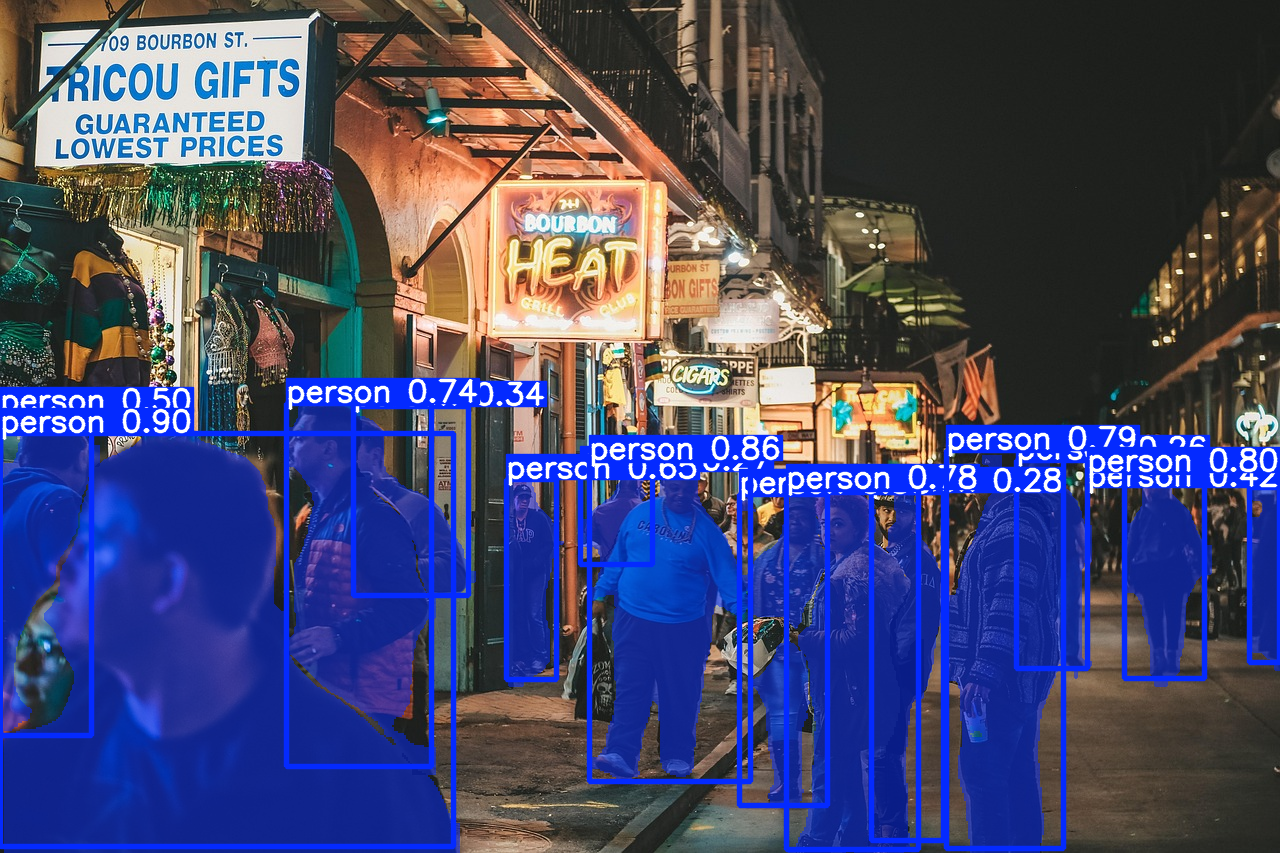

In [7]:
from collections import Counter

results = model("/content/image.jpg")

res = results[0]

class_ids = res.boxes.cls.int().tolist()

class_names = [res.names[c] for c in class_ids]

print("All detected classes:", class_names)

print("Class counts:", Counter(class_names))

res.show()

Video

In [8]:
from ultralytics import YOLO
from collections import Counter
import os

model = YOLO("yolo11n-seg.pt")

video_path = "/content/video.mp4"

results = model.predict(
    source=video_path,
    save=True,
    show=False,
    verbose=False,
    stream=False
)

output_dir = model.predictor.save_dir
output_video = os.path.join(output_dir, os.path.basename(video_path))
output_video = output_video.replace(".mp4",".avi")
print("✅ Segmented video saved at:", output_video)

WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/runs/segment/predict
✅ Segmented video saved at: /content/runs/segment/predict/video.avi


In [9]:
import moviepy.editor as mp
from IPython.display import Image, display

clip = mp.VideoFileClip(output_video)
clip = clip.speedx(2)

gif_path = "output.gif"
clip.write_gif(gif_path, fps=10, program='imageio')
display(Image(filename=gif_path))

Output hidden; open in https://colab.research.google.com to view.

Later YOLO v12 will be Avaliable just replace v11 with v12 Enjoy 😄

SAM

In [ ]:
from ultralytics import SAM

model = SAM("sam2.1_b.pt")

model.info()

Model summary: 403 layers, 80,850,178 parameters, 80,850,178 gradients


(403, 80850178, 80850178, 0.0)


image 1/1 /content/image.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 8331.2ms
Speed: 7.2ms preprocess, 8331.2ms inference, 2.5ms postprocess per image at shape (1, 3, 1024, 1024)


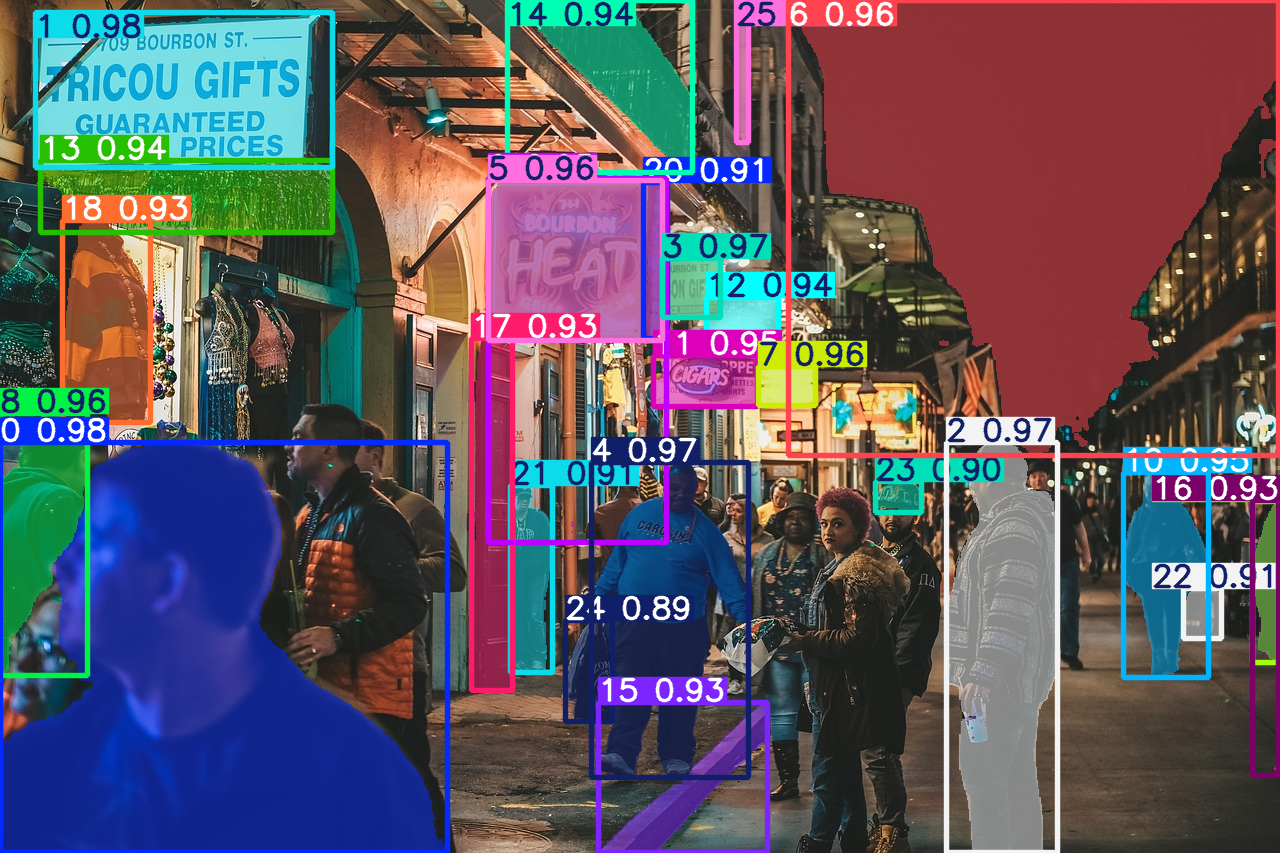

In [ ]:
results = model("/content/image.jpg")
results[0].show()

Reducing Frames, Width and Height for SAM

In [ ]:
import cv2
import os
from tqdm import tqdm

video_path = "/content/video.mp4"
cap = cv2.VideoCapture(video_path)

orig_width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
orig_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
width  = orig_width // 2
height = orig_height // 2
fps    = cap.get(cv2.CAP_PROP_FPS)

output_path = "/content/video_half.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
max_frames = min(frame_count, 200)

for _ in tqdm(range(max_frames), desc="Processing Video"):
    ret, frame = cap.read()
    if not ret:
        break
    resized_frame = cv2.resize(frame, (width, height))
    out.write(resized_frame)

cap.release()
out.release()

print(f"✅ Resized video saved at: {output_path}")
print(f"Original size: {orig_width}x{orig_height}, FPS: {fps}")
print(f"Resized size: {width}x{height}, FPS: {fps}, Frames: {max_frames}")

Processing Video: 100%|██████████| 200/200 [00:00<00:00, 282.66it/s]

✅ Resized video saved at: /content/video_half.mp4
Original size: 960x540, FPS: 30.0
Resized size: 480x270, FPS: 30.0, Frames: 200


In [ ]:
from ultralytics import YOLO
from ultralytics.models.sam import SAM2VideoPredictor
import cv2
import os

video_path = "/content/video_half.mp4"
yolo_model = YOLO("yolo11n-seg.pt")

cap = cv2.VideoCapture(video_path)
ret, first_frame = cap.read()
cap.release()

results = yolo_model(first_frame)
first_frame_boxes = results[0].boxes.xyxy.cpu().numpy()

sam_predictor = SAM2VideoPredictor(overrides={"model": "sam2.1_b.pt"})
sam_results = sam_predictor(source=video_path, bboxes=[first_frame_boxes])

output_dir = sam_predictor.save_dir
output_video = os.path.join(output_dir, os.path.basename(video_path)).replace(".mp4",".avi")
print("✅ SAM-tracked video saved at:", output_video)


0: 384x640 9 persons, 13.4ms
Speed: 2.3ms preprocess, 13.4ms inference, 6.7ms postprocess per image at shape (1, 3, 384, 640)

Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/200) /content/video_half.mp4: 640x640 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1059.1ms
video 1/1 (frame 2/200) /content/video_half.mp4: 640x640 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 278.9ms
video 1/1 (frame 3/200) /

In [ ]:
import moviepy.editor as mp
from IPython.display import Image, display

clip = mp.VideoFileClip(output_video)
clip = clip.speedx(2)
gif_path = "sam_output.gif"
clip.write_gif(gif_path, fps=10, program='imageio')
display(Image(filename=gif_path))

Output hidden; open in https://colab.research.google.com to view.